# Energy Analytics - Exploratory Data Analysis

This notebook provides an interactive analysis of the energy operations data,
including production metrics, equipment health, and emissions monitoring.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from datetime import datetime

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Database connection
conn_params = {
    'host': os.environ.get('POSTGRES_HOST', 'localhost'),
    'port': int(os.environ.get('POSTGRES_PORT', '5432')),
    'database': os.environ.get('POSTGRES_DB', 'energy_analytics'),
    'user': os.environ.get('POSTGRES_USER', 'postgres'),
    'password': os.environ.get('POSTGRES_PASSWORD', 'postgres'),
}

def query_db(sql):
    """Execute SQL query and return DataFrame."""
    with psycopg2.connect(**conn_params) as conn:
        return pd.read_sql(sql, conn)

print(f"Analysis Date: {datetime.now():%Y-%m-%d %H:%M}")

Analysis Date: 2025-12-28 23:19


## 1. Production Overview

In [2]:
# Load production data
production_df = query_db("""
    SELECT 
        well_id,
        well_name,
        operator,
        basin,
        production_date,
        oil_bbl,
        gas_mcf,
        water_bbl,
        boe_total as boe,
        water_cut_pct,
        gor_mcf_bbl as gas_oil_ratio
    FROM staging_analytics.fct_well_performance_daily
    ORDER BY production_date
""")

print(f"Total production records: {len(production_df):,}")
print(f"Date range: {production_df['production_date'].min()} to {production_df['production_date'].max()}")
print(f"Unique wells: {production_df['well_id'].nunique()}")
production_df.head()

Total production records: 930
Date range: 2025-11-29 to 2025-12-28
Unique wells: 31


/tmp/ipykernel_3349/1480903008.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,well_id,well_name,operator,basin,production_date,oil_bbl,gas_mcf,water_bbl,boe,water_cut_pct,gas_oil_ratio
0,48-925-21188,DJ Basin-Gamma-0001,ConocoPhillips,DJ Basin,2025-11-29,199.91,99.85,22.61,216.551667,10.16,0.50
1,55-298-72828,Anadarko-Alpha-0010,EOG Resources,Anadarko,2025-11-29,222.40,1158.83,174.36,415.538333,43.95,5.21
2,52-848-14665,Eagle Ford-Alpha-0029,Occidental,Eagle Ford,2025-11-29,188.49,1518.83,177.13,441.628333,48.45,8.06
3,20-642-22672,DJ Basin-Delta-0047,Devon Energy,DJ Basin,2025-11-29,506.92,914.75,115.07,659.378333,18.50,1.80
4,19-048-34119,DJ Basin-Beta-0028,Marathon Oil,DJ Basin,2025-11-29,75.14,1325.37,58.67,296.035000,43.85,17.64


In [3]:
# Production summary statistics
print("\nProduction Statistics:")
production_df[['oil_bbl', 'gas_mcf', 'water_bbl', 'boe']].describe()


Production Statistics:


,oil_bbl,gas_mcf,water_bbl,boe
count,930.000000,930.000000,930.000000,930.000000
mean,245.500333,1020.852355,103.339204,415.642392
std,118.711678,539.102939,55.512297,154.713703
min,56.050000,87.660000,10.050000,137.581667
25%,158.687500,460.570000,55.492500,313.425000
50%,212.040000,1158.410000,102.655000,401.868333
75%,342.145000,1462.880000,149.625000,520.075417
max,570.680000,2178.200000,199.790000,814.673333


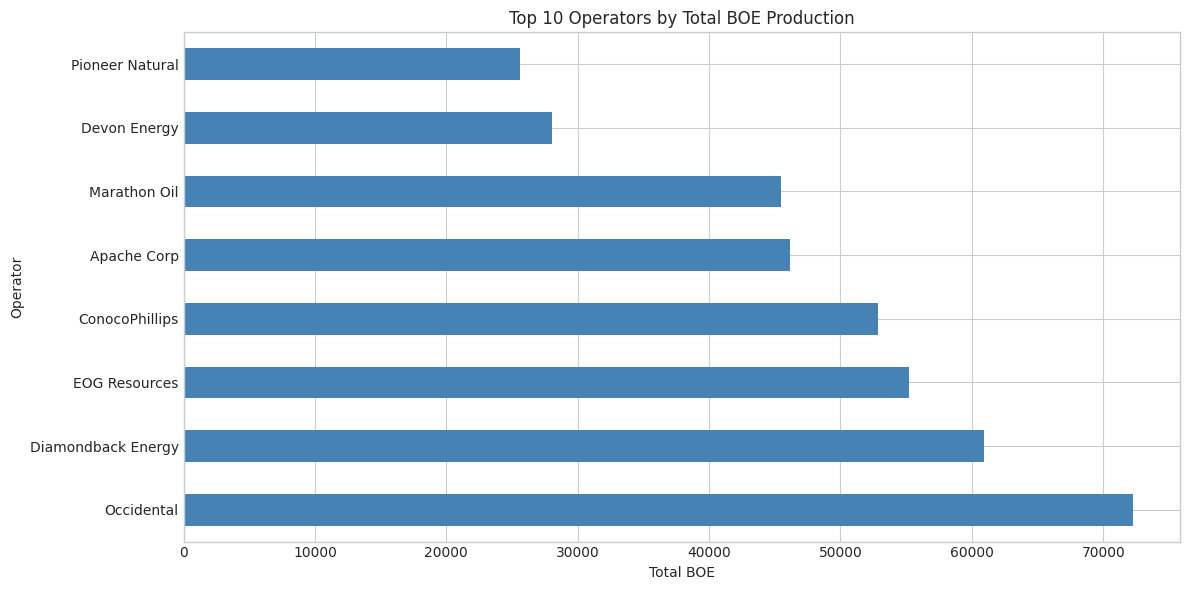

In [4]:
# Production by operator
operator_production = production_df.groupby('operator').agg({
    'oil_bbl': 'sum',
    'gas_mcf': 'sum',
    'boe': 'sum',
    'well_id': 'nunique'
}).rename(columns={'well_id': 'well_count'}).sort_values('boe', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
operator_production['boe'].head(10).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Total BOE')
ax.set_ylabel('Operator')
ax.set_title('Top 10 Operators by Total BOE Production')
plt.tight_layout()
plt.show()

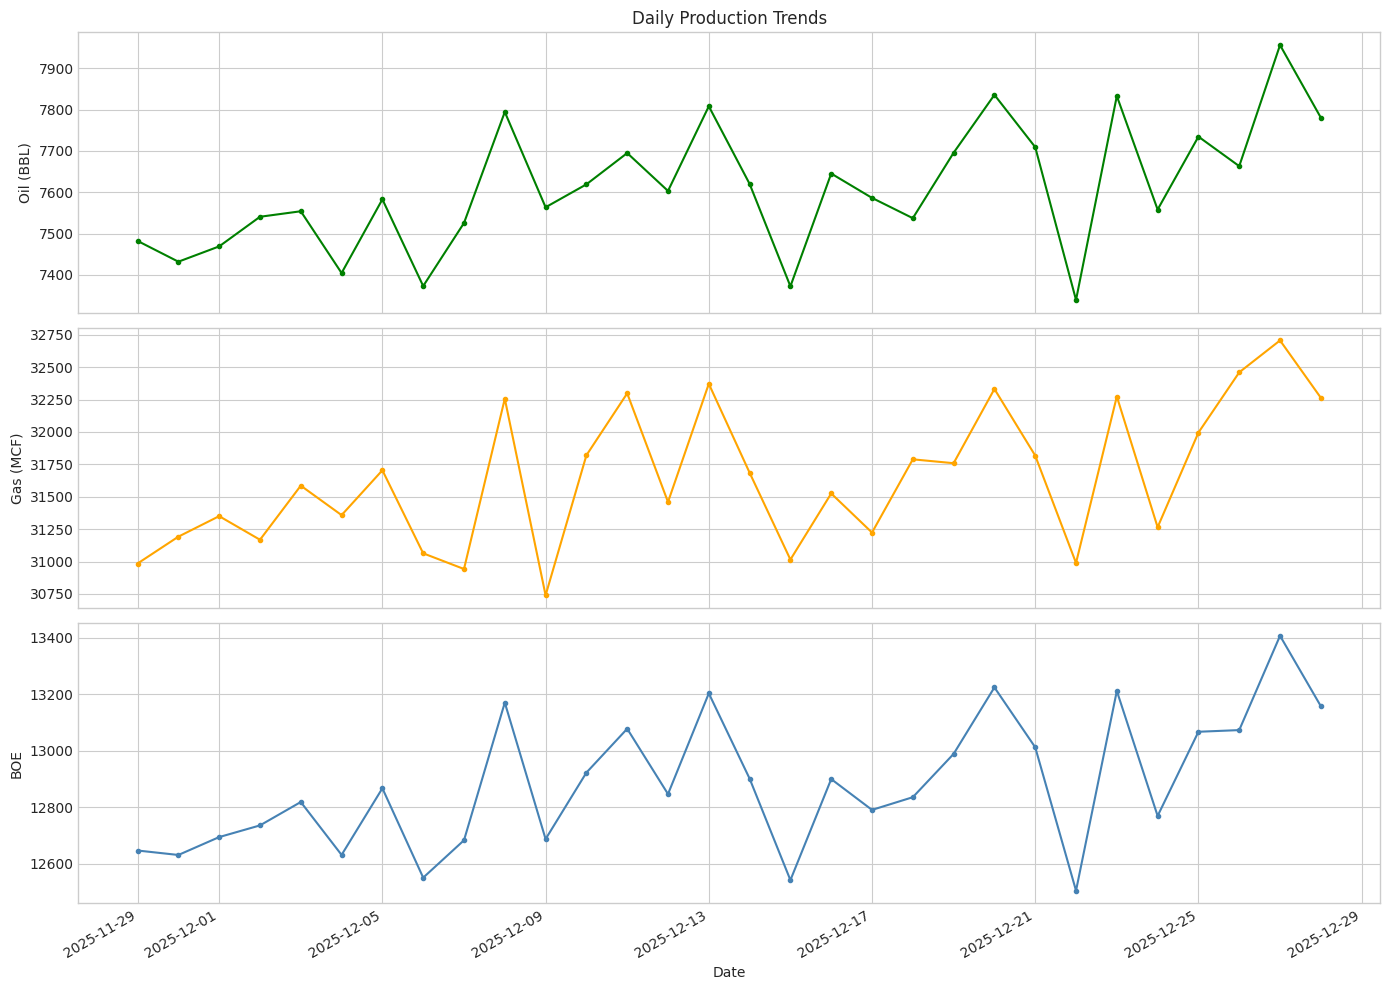

In [5]:
# Production trends over time
if 'production_date' in production_df.columns:
    # Convert to datetime and aggregate
    production_df['production_date'] = pd.to_datetime(production_df['production_date'])
    daily_production = production_df.groupby('production_date').agg({
        'oil_bbl': 'sum',
        'gas_mcf': 'sum',
        'boe': 'sum'
    }).sort_index()
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    axes[0].plot(daily_production.index, daily_production['oil_bbl'], color='green', marker='o', markersize=3)
    axes[0].set_ylabel('Oil (BBL)')
    axes[0].set_title('Daily Production Trends')
    
    axes[1].plot(daily_production.index, daily_production['gas_mcf'], color='orange', marker='o', markersize=3)
    axes[1].set_ylabel('Gas (MCF)')
    
    axes[2].plot(daily_production.index, daily_production['boe'], color='steelblue', marker='o', markersize=3)
    axes[2].set_ylabel('BOE')
    axes[2].set_xlabel('Date')
    
    # Format x-axis
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

## 2. Equipment Health Analysis

In [6]:
# Load equipment data
equipment_df = query_db("""
    SELECT 
        equipment_id,
        well_id,
        equipment_type,
        manufacturer,
        health_score,
        health_category,
        equipment_status,
        maintenance_priority_score,
        days_until_maintenance,
        is_maintenance_overdue,
        runtime_hours
    FROM staging_analytics.fct_equipment_health
""")

print(f"Total equipment records: {len(equipment_df):,}")
equipment_df.head()

Total equipment records: 7,208


/tmp/ipykernel_3349/1480903008.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,equipment_id,well_id,equipment_type,manufacturer,health_score,health_category,equipment_status,maintenance_priority_score,days_until_maintenance,is_maintenance_overdue,runtime_hours
0,BFCBA63E,54-835-83515,Pump Jack,Dover,60.2,Fair,Maintenance,119.8,49,False,38907
1,2BF3901A,48-925-21188,SCADA System,Honeywell,60.7,Fair,Degraded,119.3,12,False,45577
2,500CF322,32-642-15367,Tank Battery,CECO,61.2,Fair,Maintenance,118.8,165,False,26881
3,8CE1DFA3,32-642-15367,Tank Battery,CECO,61.2,Fair,Maintenance,118.8,165,False,26881
4,313A10BE,32-642-15367,Tank Battery,CECO,61.2,Fair,Maintenance,118.8,165,False,26881


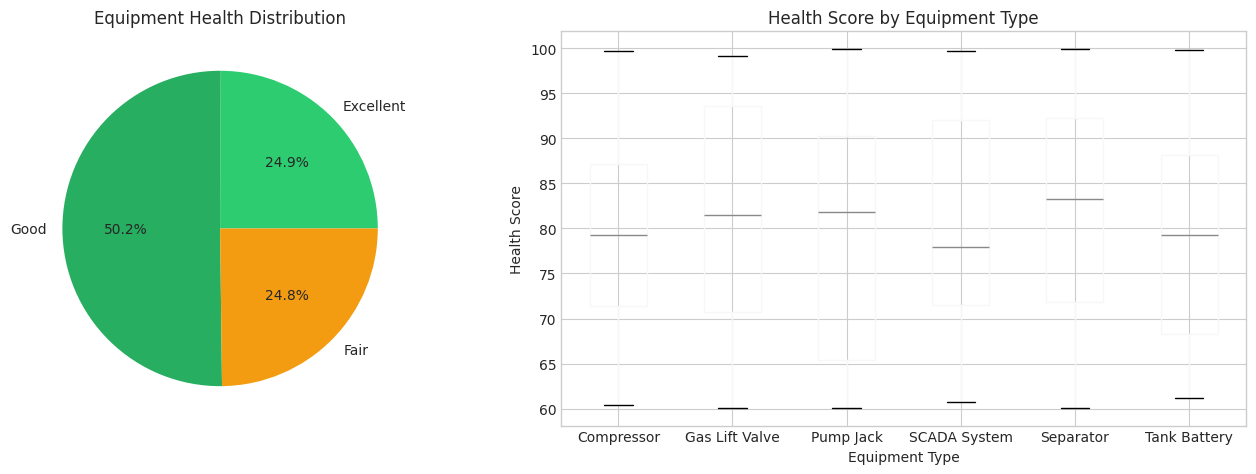

In [7]:
# Equipment health distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Health category distribution
health_counts = equipment_df['health_category'].value_counts()
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#c0392b']
health_order = ['Excellent', 'Good', 'Fair', 'Poor', 'Critical']
health_counts = health_counts.reindex([c for c in health_order if c in health_counts.index])
health_counts.plot(kind='pie', ax=axes[0], colors=colors[:len(health_counts)], autopct='%1.1f%%')
axes[0].set_title('Equipment Health Distribution')
axes[0].set_ylabel('')

# Health score by equipment type
equipment_df.boxplot(column='health_score', by='equipment_type', ax=axes[1])
axes[1].set_title('Health Score by Equipment Type')
axes[1].set_xlabel('Equipment Type')
axes[1].set_ylabel('Health Score')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [8]:
# Equipment requiring attention
critical_equipment = equipment_df[
    (equipment_df['health_category'].isin(['Poor', 'Critical'])) |
    (equipment_df['is_maintenance_overdue'] == True)
].sort_values('maintenance_priority_score', ascending=False)

print(f"Equipment requiring attention: {len(critical_equipment)}")
critical_equipment[['equipment_id', 'well_id', 'equipment_type', 'health_score', 
                    'health_category', 'is_maintenance_overdue', 'maintenance_priority_score']].head(10)

Equipment requiring attention: 0


,equipment_id,well_id,equipment_type,health_score,health_category,is_maintenance_overdue,maintenance_priority_score


## 3. Emissions Analysis

In [9]:
# Load emissions data
emissions_df = query_db("""
    SELECT 
        well_id,
        measurement_date,
        methane_kg,
        co2_kg,
        voc_kg,
        co2_equivalent_kg,
        flare_volume_mcf,
        leak_detected,
        environmental_risk as risk_level
    FROM staging_analytics.fct_emissions_daily
    ORDER BY measurement_date
""")

print(f"Total emissions records: {len(emissions_df):,}")
emissions_df.head()

Total emissions records: 1,500


/tmp/ipykernel_3349/1480903008.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,well_id,measurement_date,methane_kg,co2_kg,voc_kg,co2_equivalent_kg,flare_volume_mcf,leak_detected,risk_level
0,36-764-50564,2025-11-29,63.27,206.09,16.67,1787.84,36.40,True,High
1,41-464-92197,2025-11-29,24.97,242.04,15.64,866.29,11.63,False,Low-Medium
2,12-317-64347,2025-11-29,45.30,218.93,10.60,1351.43,25.79,False,Low-Medium
3,48-834-81555,2025-11-29,17.17,430.91,3.07,860.16,28.92,False,Medium
4,32-642-15367,2025-11-29,38.11,242.34,18.47,1195.09,37.02,False,Low-Medium


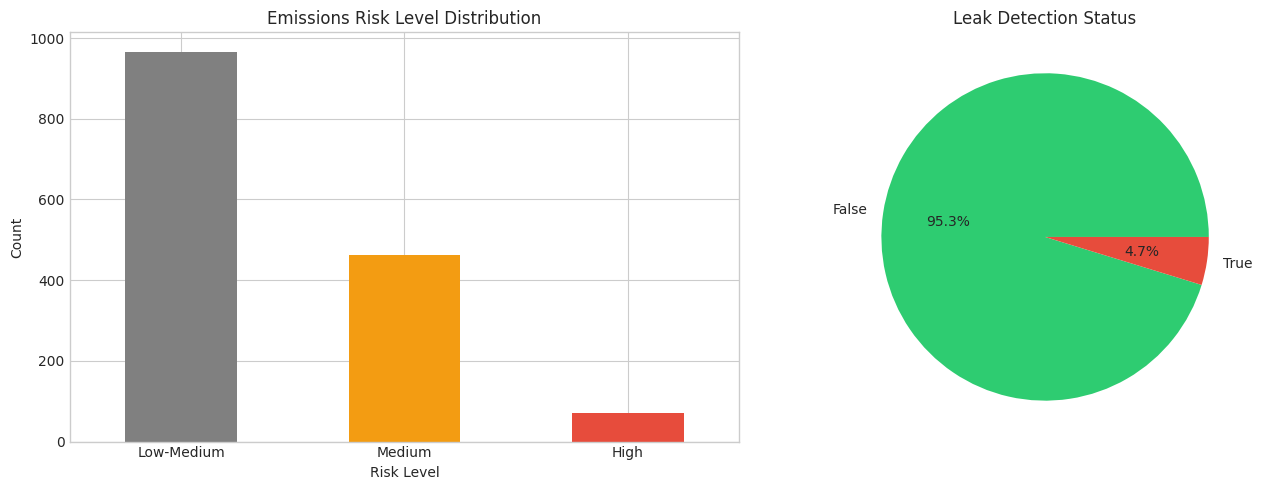

In [10]:
# Emissions summary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk level distribution
risk_counts = emissions_df['risk_level'].value_counts()
risk_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
risk_counts.plot(kind='bar', ax=axes[0], color=[risk_colors.get(r, 'gray') for r in risk_counts.index])
axes[0].set_title('Emissions Risk Level Distribution')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Leak detection
leak_counts = emissions_df['leak_detected'].value_counts()
leak_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Leak Detection Status')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

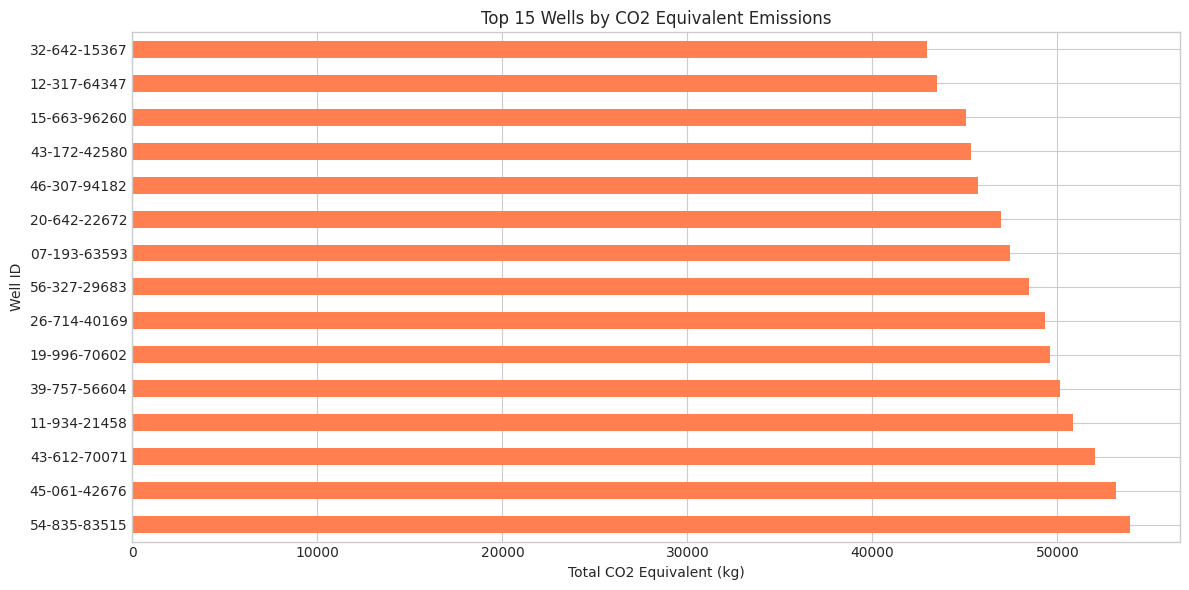

In [11]:
# CO2 equivalent emissions by well (top emitters)
well_emissions = emissions_df.groupby('well_id').agg({
    'co2_equivalent_kg': 'sum',
    'methane_kg': 'sum',
    'flare_volume_mcf': 'sum'
}).sort_values('co2_equivalent_kg', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
well_emissions['co2_equivalent_kg'].head(15).plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Total CO2 Equivalent (kg)')
ax.set_ylabel('Well ID')
ax.set_title('Top 15 Wells by CO2 Equivalent Emissions')
plt.tight_layout()
plt.show()

## 4. Operator Summary

In [12]:
# Load operator summary
operator_df = query_db("""
    SELECT *
    FROM staging_analytics.dim_operator_summary
    ORDER BY total_boe_30d DESC
""")

print(f"Total operators: {len(operator_df)}")
operator_df

Total operators: 8


/tmp/ipykernel_3349/1480903008.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,operator,total_wells,active_wells,inactive_wells,plugged_wells,basins_operated,states_operated,avg_well_age_days,total_oil_bbl_30d,total_gas_mcf_30d,...,critical_equipment,high_risk_equipment,overdue_maintenance_count,total_equipment_alerts,total_methane_kg_30d,total_co2e_kg_30d,leak_events_30d,total_flare_mcf_30d,oil_per_active_well_30d,model_run_at
0,Diamondback Energy,39,26,8,5,7,7,1935.0,59831.16,281772.14,...,0,0,0,1472,9506.80,310341.48,15,5875.69,2301.20,2025-12-28 23:15:20.712034+00:00
1,Occidental,44,33,5,6,7,7,2085.0,62927.20,233403.22,...,0,0,0,1544,8425.58,282797.40,10,5838.04,1906.88,2025-12-28 23:15:20.712034+00:00
2,EOG Resources,48,31,12,5,7,7,1761.0,57165.63,257890.05,...,0,0,0,1757,7131.04,252293.01,11,5874.97,1844.05,2025-12-28 23:15:20.712034+00:00
3,Marathon Oil,40,27,6,7,7,7,1851.0,53494.49,276495.41,...,0,0,0,1341,9510.87,316916.26,11,6789.61,1981.28,2025-12-28 23:15:20.712034+00:00
4,ConocoPhillips,44,30,10,4,7,7,2106.0,64152.82,205527.10,...,0,0,0,1090,7461.34,250066.08,9,5059.81,2138.43,2025-12-28 23:15:20.712034+00:00
5,Apache Corp,45,32,8,5,7,7,2138.0,33300.37,142619.64,...,0,0,0,436,3229.17,115790.14,7,3005.25,1040.64,2025-12-28 23:15:20.712034+00:00
6,Pioneer Natural,41,32,6,3,7,7,1971.0,30170.69,103782.51,...,0,0,0,705,4027.97,126358.44,5,2140.50,942.83,2025-12-28 23:15:20.712034+00:00
7,Devon Energy,49,36,9,4,7,7,2150.0,28705.97,82099.96,...,0,0,0,676,3760.52,120769.16,3,2290.61,797.39,2025-12-28 23:15:20.712034+00:00


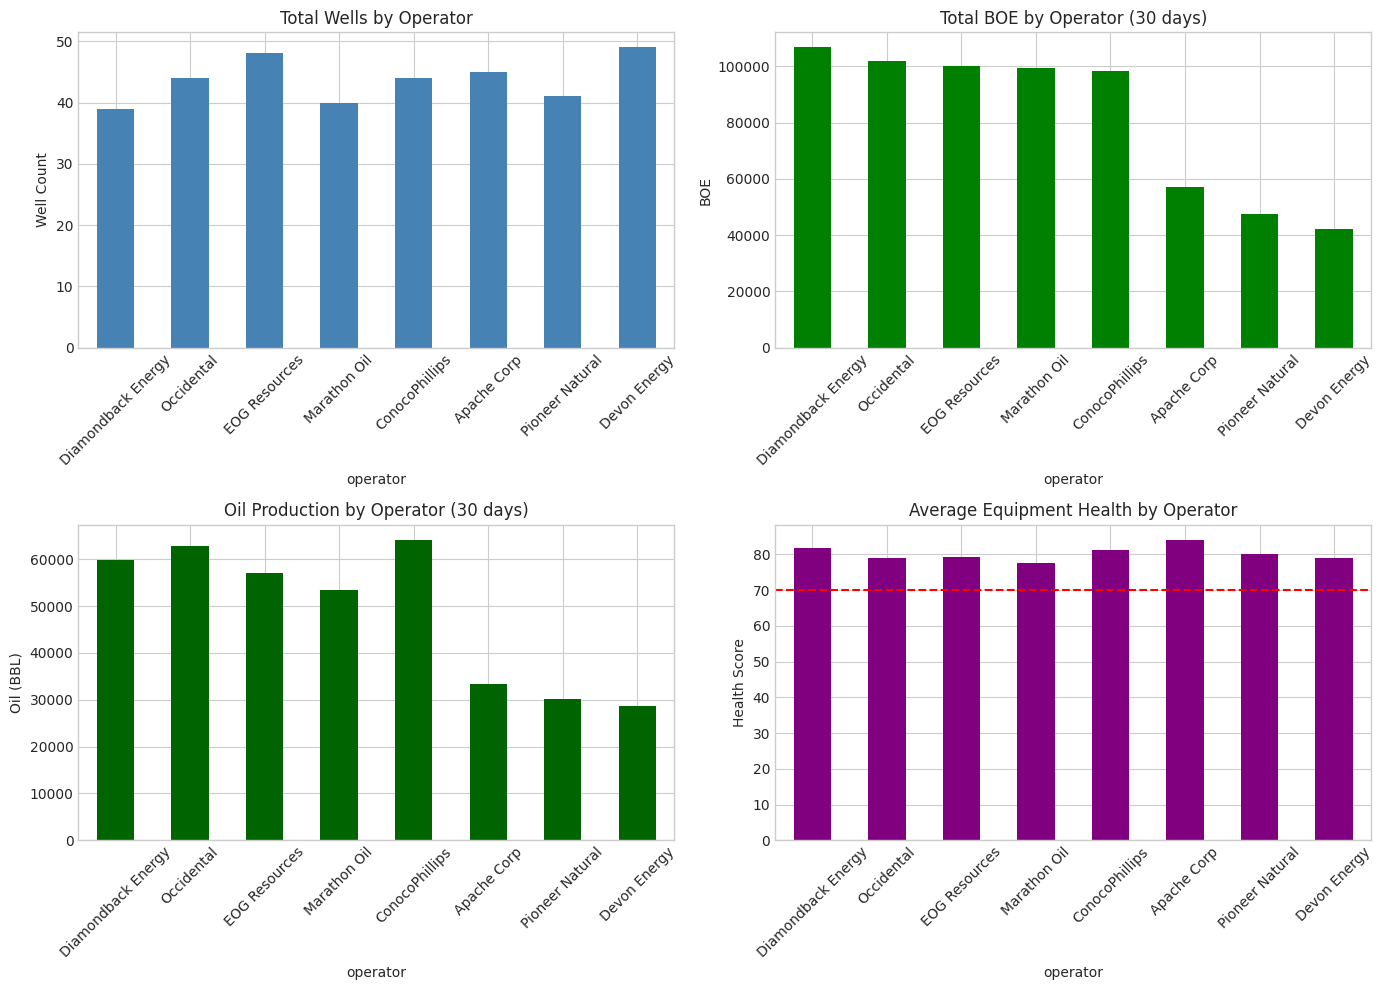

In [13]:
# Operator comparison
if len(operator_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Wells count
    operator_df.set_index('operator')['total_wells'].plot(
        kind='bar', ax=axes[0, 0], color='steelblue'
    )
    axes[0, 0].set_title('Total Wells by Operator')
    axes[0, 0].set_ylabel('Well Count')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # BOE Production
    operator_df.set_index('operator')['total_boe_30d'].plot(
        kind='bar', ax=axes[0, 1], color='green'
    )
    axes[0, 1].set_title('Total BOE by Operator (30 days)')
    axes[0, 1].set_ylabel('BOE')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Revenue
    operator_df.set_index('operator')['total_oil_bbl_30d'].plot(
        kind='bar', ax=axes[1, 0], color='darkgreen'
    )
    axes[1, 0].set_title('Oil Production by Operator (30 days)')
    axes[1, 0].set_ylabel('Oil (BBL)')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Equipment Health
    operator_df.set_index('operator')['avg_equipment_health'].plot(
        kind='bar', ax=axes[1, 1], color='purple'
    )
    axes[1, 1].set_title('Average Equipment Health by Operator')
    axes[1, 1].set_ylabel('Health Score')
    axes[1, 1].axhline(y=70, color='red', linestyle='--', label='Threshold')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 5. Key Findings Summary

In [14]:
# Generate key findings
print("=" * 60)
print("KEY FINDINGS SUMMARY")
print("=" * 60)

# Production highlights
print("\n📊 PRODUCTION METRICS:")
print(f"  • Total wells analyzed: {production_df['well_id'].nunique():,}")
print(f"  • Total oil production: {production_df['oil_bbl'].sum():,.0f} BBL")
print(f"  • Total gas production: {production_df['gas_mcf'].sum():,.0f} MCF")
print(f"  • Total BOE: {production_df['boe'].sum():,.0f}")

# Equipment highlights
print("\n🔧 EQUIPMENT HEALTH:")
critical_count = len(equipment_df[equipment_df['health_category'].isin(['Poor', 'Critical'])])
print(f"  • Total equipment: {len(equipment_df):,}")
print(f"  • Average health score: {equipment_df['health_score'].mean():.1f}")
print(f"  • Critical/Poor equipment: {critical_count} ({100*critical_count/len(equipment_df):.1f}%)")

# Emissions highlights
print("\n🌿 EMISSIONS:")
leak_count = len(emissions_df[emissions_df['leak_detected'] == True])
print(f"  • Total CO2 equivalent: {emissions_df['co2_equivalent_kg'].sum():,.0f} kg")
print(f"  • Detected leaks: {leak_count}")
high_risk = len(emissions_df[emissions_df['risk_level'] == 'High'])
print(f"  • High risk readings: {high_risk}")

print("\n" + "=" * 60)

KEY FINDINGS SUMMARY

📊 PRODUCTION METRICS:
  • Total wells analyzed: 31
  • Total oil production: 228,315 BBL
  • Total gas production: 949,393 MCF
  • Total BOE: 386,547

🔧 EQUIPMENT HEALTH:
  • Total equipment: 7,208
  • Average health score: 80.1
  • Critical/Poor equipment: 0 (0.0%)

🌿 EMISSIONS:
  • Total CO2 equivalent: 1,775,332 kg
  • Detected leaks: 71
  • High risk readings: 71

